In [402]:
import pandas as pd
import numpy as np

In [403]:
volunteer = pd.read_csv('/content/Housing Price Prediction Data.csv')
volunteer.head()


,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4.0,1,Rural,1969,215355.2836
1,2459,3.0,2,Rural,1980,195014.2216
2,1860,2.0,1,Suburb,1970,306891.0121
3,2294,2.0,1,Urban,1996,206786.7872
4,2130,5.0,2,Suburb,2001,272436.2391


In [404]:
volunteer.shape

(3502, 6)

In [405]:
volunteer.isnull().sum()

,0
SquareFeet,0
Bedrooms,35
Bathrooms,0
Neighborhood,0
YearBuilt,0
Price,0


In [406]:
volunteer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    3502 non-null   int64  
 1   Bedrooms      3467 non-null   float64
 2   Bathrooms     3502 non-null   int64  
 3   Neighborhood  3502 non-null   object 
 4   YearBuilt     3502 non-null   int64  
 5   Price         3502 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 164.3+ KB


In [407]:
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='median')

impute.fit(volunteer[['Bedrooms']])

volunteer['Bedrooms'] = impute.transform(volunteer[['Bedrooms']])

In [408]:
volunteer.isnull().sum()

,0
SquareFeet,0
Bedrooms,0
Bathrooms,0
Neighborhood,0
YearBuilt,0
Price,0


**removing duplicate rows (if present),here we can see no duplicate row present**

In [409]:
volunteer.duplicated().sum()

0

In [410]:
volunteer['Neighborhood'].unique()

array(['Rural', 'Suburb', 'Urban'], dtype=object)

In [411]:

volunteer = pd.get_dummies(volunteer,columns=['Neighborhood'],dtype='int')

volunteer.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4.0,1,1969,215355.2836,1,0,0
1,2459,3.0,2,1980,195014.2216,1,0,0
2,1860,2.0,1,1970,306891.0121,0,1,0
3,2294,2.0,1,1996,206786.7872,0,0,1
4,2130,5.0,2,2001,272436.2391,0,1,0


** Removing 1-2 variables using correlation as feature selection**

In [412]:
volunteer_corr = volunteer.corr()
volunteer_corr.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban
SquareFeet,1.000000,-0.003843,-0.020497,0.009925,0.743367,0.004047,0.003710,-0.007835
Bedrooms,-0.003843,1.000000,0.036234,0.010835,0.070281,0.012929,0.007770,-0.020919
Bathrooms,-0.020497,0.036234,1.000000,0.025003,0.033923,0.039540,-0.002451,-0.037575
YearBuilt,0.009925,0.010835,0.025003,1.000000,0.009422,0.000280,0.010803,-0.011162
Price,0.743367,0.070281,0.033923,0.009422,1.000000,0.004346,-0.007145,0.002794


 **Corelation Heatmap before removing a feature**



<Axes: >

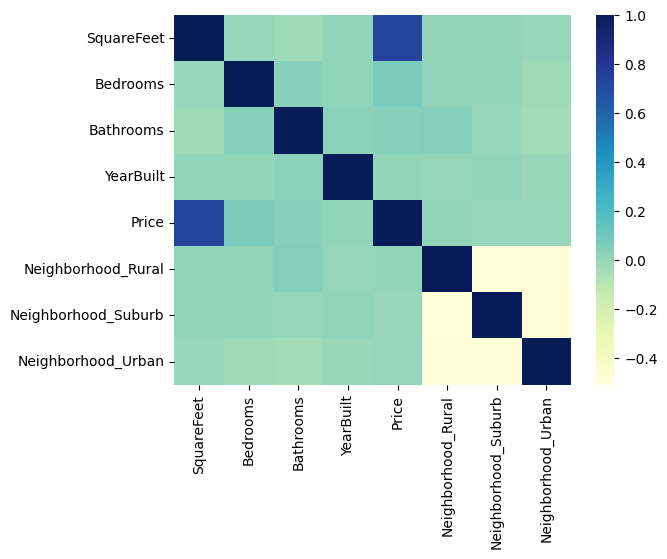

In [413]:
import seaborn as sns
sns.heatmap(volunteer_corr, cmap = 'YlGnBu')

In [414]:
selected_corelation=volunteer.drop(['SquareFeet',],axis=1)

**Heatmap after removing the feature**

<Axes: >

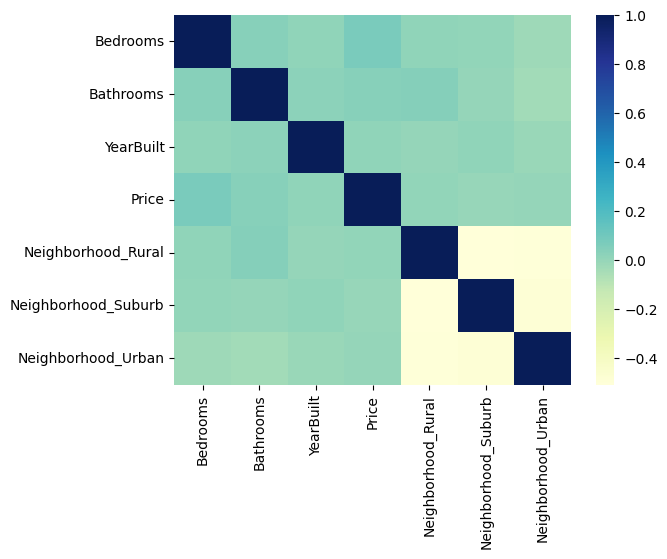

In [415]:
import seaborn as sns
house_price_corr=selected_corelation.corr()
sns.heatmap(house_price_corr, cmap = 'YlGnBu')

In [416]:
from sklearn.model_selection import train_test_split

a=selected_corelation.drop('Price',axis=1)

b=selected_corelation['Price']

X_train, X_test, y_train, y_test = train_test_split(a, b,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2626, 6)
(876, 6)
(2626,)
(876,)


mean_squared_error:5726900196.19
root_mean_squared_error:75676.29
-0.004707802497483371


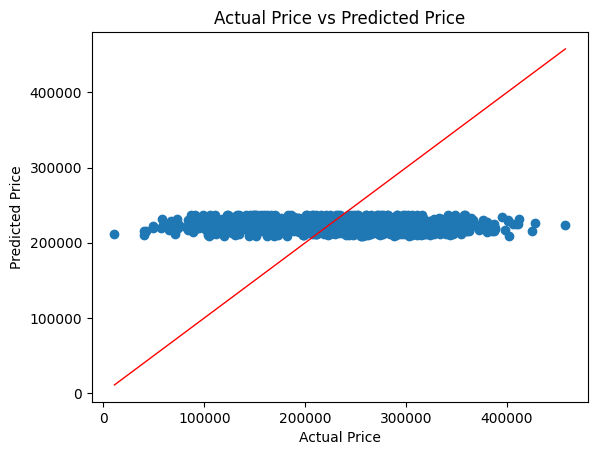

In [417]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

model1=LinearRegression()
model1.fit(X_train,y_train)
y_prediction=model1.predict(X_test)
mse=mean_squared_error(y_test,y_prediction)
rmse=np.sqrt(mse)
mse=(f'mean_squared_error:{mse:.2f}')
print(mse)
rmse=(f'root_mean_squared_error:{rmse:.2f}')
print(rmse)
print(r2_score(y_test,y_prediction))


plt.scatter(y_test,y_prediction)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r',lw=1)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price vs Predicted Price')
plt.show()

In [418]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score
import seaborn as sns


In [419]:
t1=210000
def classify (volunteer):
  if volunteer>t1:
    return 0
  else:
    return 1
selected_corelation['pricing_class']=selected_corelation['Price'].apply(classify)

In [420]:
selected_corelation.head()

,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Rural,Neighborhood_Suburb,Neighborhood_Urban,pricing_class
0,4.0,1,1969,215355.2836,1,0,0,0
1,3.0,2,1980,195014.2216,1,0,0,1
2,2.0,1,1970,306891.0121,0,1,0,0
3,2.0,1,1996,206786.7872,0,0,1,1
4,5.0,2,2001,272436.2391,0,1,0,0


In [421]:
x=selected_corelation.drop(['Price','pricing_class'],axis=1)
y=selected_corelation['pricing_class']
x_train2,x_test2,y_train2,y_test2=train_test_split(x,y,test_size=0.25,random_state=30)
model2=LogisticRegression()
model2.fit(x_train2,y_train2)
y_pred=model2.predict(x_test2)
print(y_pred)


[0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

In [422]:
print (confusion_matrix(y_test2,y_pred))
print (classification_report(y_test2,y_pred))

print (accuracy_score(y_test2,y_pred))

[[485  14]
 [366  11]]
              precision    recall  f1-score   support

           0       0.57      0.97      0.72       499
           1       0.44      0.03      0.05       377

    accuracy                           0.57       876
   macro avg       0.50      0.50      0.39       876
weighted avg       0.51      0.57      0.43       876

0.5662100456621004
